In [ ]:
import sys
sys.path.append('../datasets')
sys.path.append('../algorithms')
sys.path.append('../test')


import torch

import matplotlib.pyplot as plt


from pansharpening import PANDataset
from alg3 import PANTVGradAlignment
from torchvision import transforms
from math import sqrt
from nabla import nabla

/home/ndiayem/Documents/spectral-spatial/env/lib/python3.11/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [201]:
#Define device (default is "cpu")
device = "cpu" 

    # Define dtype
dtype = torch.float64
crop_size = 256

    # Define random seed
seed = 42
torch.manual_seed(seed)

    # Define data path
data_path = '/home/ndiayem/Documents/spectral-spatial/data/harvard.zarr'

In [365]:
val_transform = transforms.Compose([transforms.CenterCrop(crop_size)]) # Transforms a the input data to torch tensors
dataset = PANDataset(root_dir=data_path, split='train' ,transform=val_transform,normalize= True,scale=4,sigma=0.001,sigma1 = 0.01,device='cpu', size=crop_size)

In [434]:
idx = 7
X = dataset[idx]
X = X.unsqueeze(0)

In [435]:
X.shape

torch.Size([1, 31, 256, 256])

In [436]:
# Matrice de transformation
Y_H = dataset.simulate_low_res_hsi(X)  
Y_M = dataset.get_panchromatic(X)

In [438]:
def display_pan_gradient_analysis(pan_image, alpha=0.02):
    """
    Affiche l'image panchromatique, la norme de son gradient, le critère c_n et son histogramme.
    
    Args:
        pan_image (torch.Tensor): Image panchromatique [1,1,H,W]
        alpha (float): Seuil pour les contours du critère c_n
    """
    # Création de la figure avec une disposition en 2 lignes
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 0.5])
    
    # ========================================================
    # 1. Image panchromatique originale
    # ========================================================
    ax1 = fig.add_subplot(gs[0, 0])
    pan_np = pan_image[0, 0].cpu().numpy()
    img_plot = ax1.imshow(pan_np, cmap='gray')
    plt.colorbar(img_plot, ax=ax1, fraction=0.046, pad=0.04)
    ax1.set_title('Image panchromatique')
    ax1.axis('off')

    # ========================================================
    # 2. Calcul du gradient et critère
    # ========================================================
    with torch.no_grad():
        grad = nabla(pan_image)  # Shape [1,1,H,W,2]
        grad_norm = torch.norm(grad.squeeze(), dim=-1)  # Shape [H,W]
        
        # Normalisation robuste
        vmax = torch.quantile(grad_norm, 0.98).item()
        grad_norm_normalized = (grad_norm / vmax).clamp(0, 1)
        
        # Critère c_n
        criterion = grad_norm / (grad_norm.sum() + 1e-7)
        criterion_normalized = criterion / torch.quantile(criterion, 0.98)
        c_n = criterion_normalized.cpu().numpy()

    # ========================================================
    # 3. Norme du gradient
    # ========================================================
    ax2 = fig.add_subplot(gs[0, 1])
    grad_plot = ax2.imshow(grad_norm_normalized.cpu(), cmap='gray')
    plt.colorbar(grad_plot, ax=ax2, fraction=0.046, pad=0.04)
    ax2.set_title('Norme du gradient (||∇P||)')
    ax2.axis('off')

    # ========================================================
    # 4. Critère c_n avec contours
    # ========================================================
    ax3 = fig.add_subplot(gs[0, 2])
    crit_plot = ax3.imshow(c_n, cmap='gray', vmin=0, vmax=0.5)
    if alpha is not None:
        ax3.contour(c_n > alpha, colors='red', linewidths=0.8, alpha=0.7)
    plt.colorbar(crit_plot, ax=ax3, fraction=0.046, pad=0.04)
    ax3.set_title(f'Critère c_n (α={alpha})')
    ax3.axis('off')

    # ========================================================
    # 5. Histogramme du critère c_n (pleine largeur)
    # ========================================================
    ax4 = fig.add_subplot(gs[1, :])  # Prend toute la largeur
    n, bins, patches = ax4.hist(c_n.flatten(), bins=100, log=True, 
                               color='blue', edgecolor='black')
    
    # Mise en valeur du seuil alpha
    if alpha is not None:
        ax4.axvline(x=alpha, color='red', linestyle='--', linewidth=2)
        ax4.text(alpha*1.1, ax4.get_ylim()[1]*0.9, 
                f'Seuil α={alpha}', color='red')
    
    ax4.set_xlabel('Valeur du critère c_n')
    ax4.set_ylabel('Fréquence (log)')
    ax4.set_title('Distribution du critère c_n')
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [439]:
from skimage.filters import threshold_otsu
def display_pan_gradient_analysis(pan_image):
    """
    Affiche l'image panchromatique, la norme de son gradient, le critère c_n et son histogramme.
    
    Args:
        pan_image (torch.Tensor): Image panchromatique [1,1,H,W]
        alpha (float): Seuil pour les contours du critère c_n
    """
    # Création de la figure avec une disposition en 2 lignes
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 0.5])
    
    # ========================================================
    # 1. Image panchromatique originale
    # ========================================================
    ax1 = fig.add_subplot(gs[0, 0])
    pan_np = pan_image[0, 0].cpu().numpy()
    img_plot = ax1.imshow(pan_np, cmap='gray')
    plt.colorbar(img_plot, ax=ax1, fraction=0.046, pad=0.04)
    ax1.set_title('Image panchromatique')
    ax1.axis('off')

    # ========================================================
    # 2. Calcul du gradient et critère
    # ========================================================
    with torch.no_grad():
        grad = nabla(pan_image)  # Shape [1,1,H,W,2]
        grad_norm = torch.norm(grad.squeeze(), dim=-1)  # Shape [H,W]
        
        # Normalisation robuste
        vmax = torch.quantile(grad_norm, 0.98).item()
        grad_norm_normalized = (grad_norm / vmax).clamp(0, 1)
        
        # Critère c_n
        criterion = grad_norm / (grad_norm.sum() + 1e-7)
        criterion_normalized = criterion / torch.quantile(criterion, 0.98)
        c_n = criterion_normalized.cpu().numpy()
        alpha = threshold_otsu(c_n)

    # ========================================================
    # 3. Norme du gradient
    # ========================================================
    ax2 = fig.add_subplot(gs[0, 1])
    grad_plot = ax2.imshow(grad_norm_normalized.cpu(), cmap='gray')
    plt.colorbar(grad_plot, ax=ax2, fraction=0.046, pad=0.04)
    ax2.set_title('Norme du gradient (||∇P||)')
    ax2.axis('off')

    # ========================================================
    # 4. Critère c_n avec contours
    # ========================================================
    ax3 = fig.add_subplot(gs[0, 2])
    crit_plot = ax3.imshow(c_n, cmap='gray', vmin=0, vmax=0.5)
    if alpha is not None:
        ax3.contour(c_n > alpha, colors='red', linewidths=0.8, alpha=0.7)
    plt.colorbar(crit_plot, ax=ax3, fraction=0.046, pad=0.04)
    ax3.set_title(f'Critère c_n (α={alpha})')
    ax3.axis('off')

    # ========================================================
    # 5. Histogramme du critère c_n (pleine largeur)
    # ========================================================
    ax4 = fig.add_subplot(gs[1, :])  # Prend toute la largeur
    n, bins, patches = ax4.hist(c_n.flatten(), bins=100, log=True, 
                               color='blue', edgecolor='black')
    
    # Mise en valeur du seuil alpha
    if alpha is not None:
        ax4.axvline(x=alpha, color='red', linestyle='--', linewidth=2)
        ax4.text(alpha*1.1, ax4.get_ylim()[1]*0.9, 
                f'Seuil α={alpha}', color='red')
    
    ax4.set_xlabel('Valeur du critère c_n')
    ax4.set_ylabel('Fréquence (log)')
    ax4.set_title('Distribution du critère c_n')
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

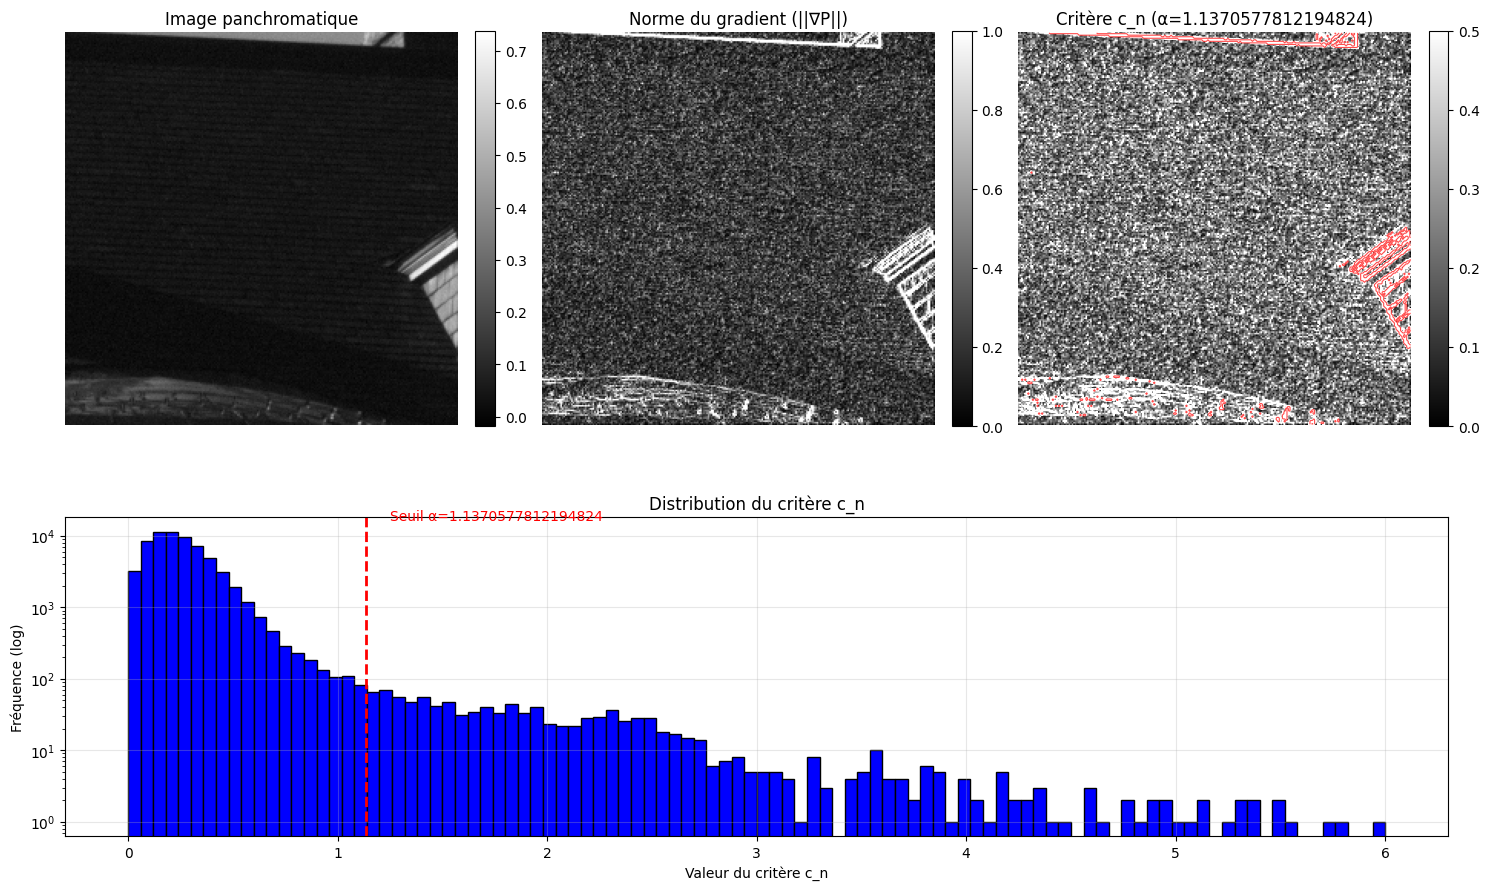

In [440]:
# Utilisation
display_pan_gradient_analysis(Y_M)  # Ajustez alpha au besoin

In [506]:
grad_panc = nabla(Y_M)
params = {
    'max_iter': 300,         # niters → max_iter (nom attendu par TVPrior)
    'lmbda': 0.04,          # paramètre supplémentaire
    'theta': 1 ,            # paramètre de régularisation
    'sigma': 2,                  # sigma = gain (gain=2)   
    'tau': 0.99/2,            # tau = 0.99 / gain (calculé)
    'grad_panc' : grad_panc,  # le gradient de la panchromatique
    'threshold_type' : 'soft',
    'alpha' : 1.13,
    'threshold_param'  : 0.1
}


In [513]:
A,A_adj, R, R_adj = dataset.get_operators()

solver_gp = PANTVGradAlignment(
    A=A,
    Aadj=A_adj,
    spectral_op = dataset.spectral_op,
    spectral_op_t = dataset.spectral_op_t,
    max_iter=10,
    lmbda=0.04,
    lmbda_m=1,
    tol=1e-7,
    scale=dataset.scale,
    p = 2,
    q = 2,
    r = 1,
    verbose=True,
    params = params
)

In [ ]:
U_cb, costs_gp = solver_gp(Y_H, Y_M)


Début de l'optimisation:
It    | Coût total   | Data H       | Data M       | TV           | ΔU          
--------------------------------------------------------------------------------
0     | 6.627e+02    | 4.079e+02    | 2.536e+02    | 1.206e+00    | 5.807e-02   


In [509]:
U_cb.shape

torch.Size([1, 31, 256, 256])

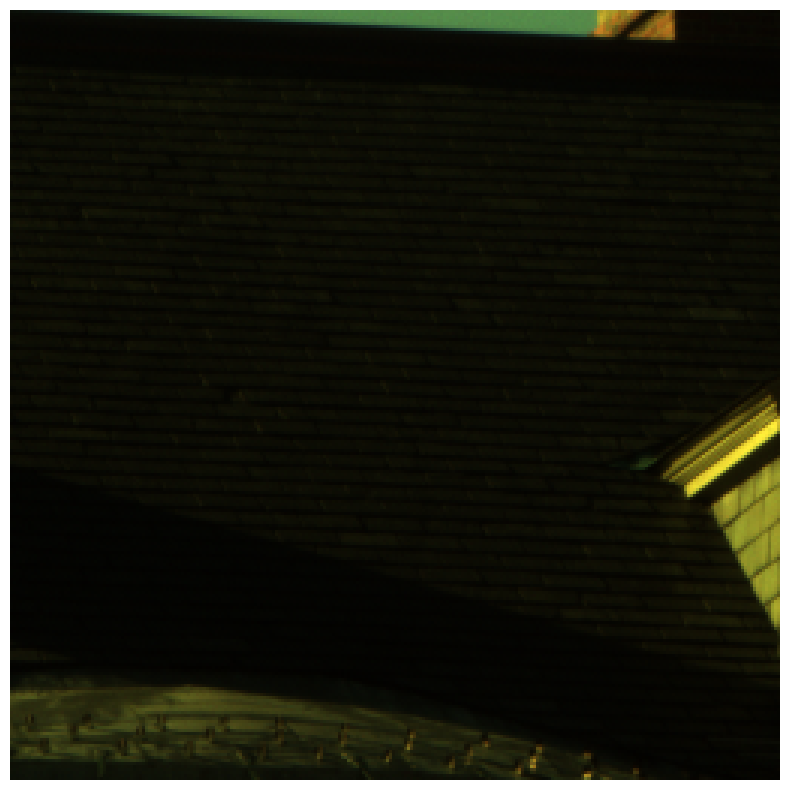

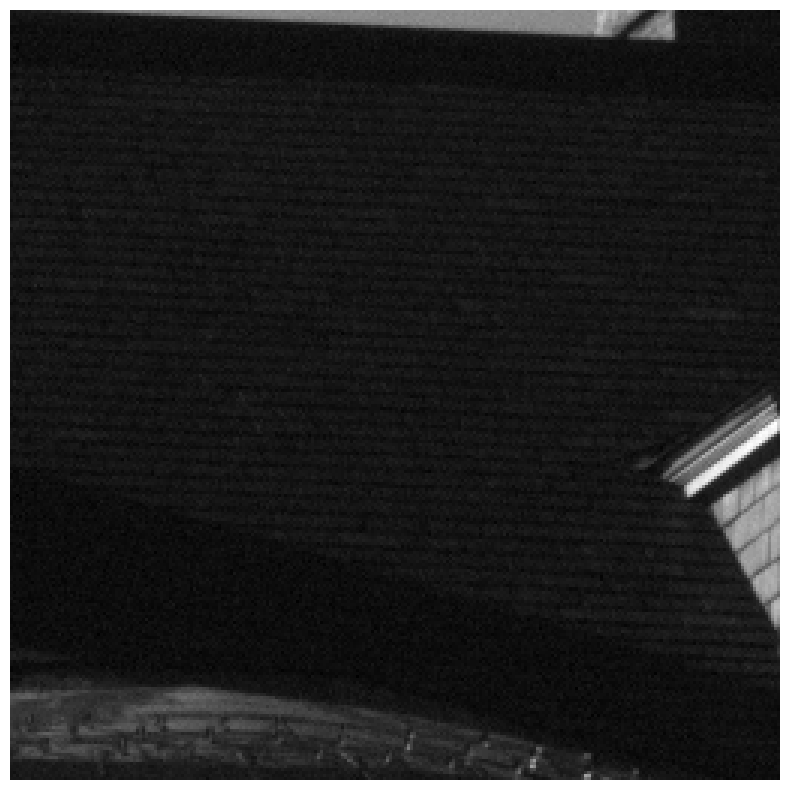

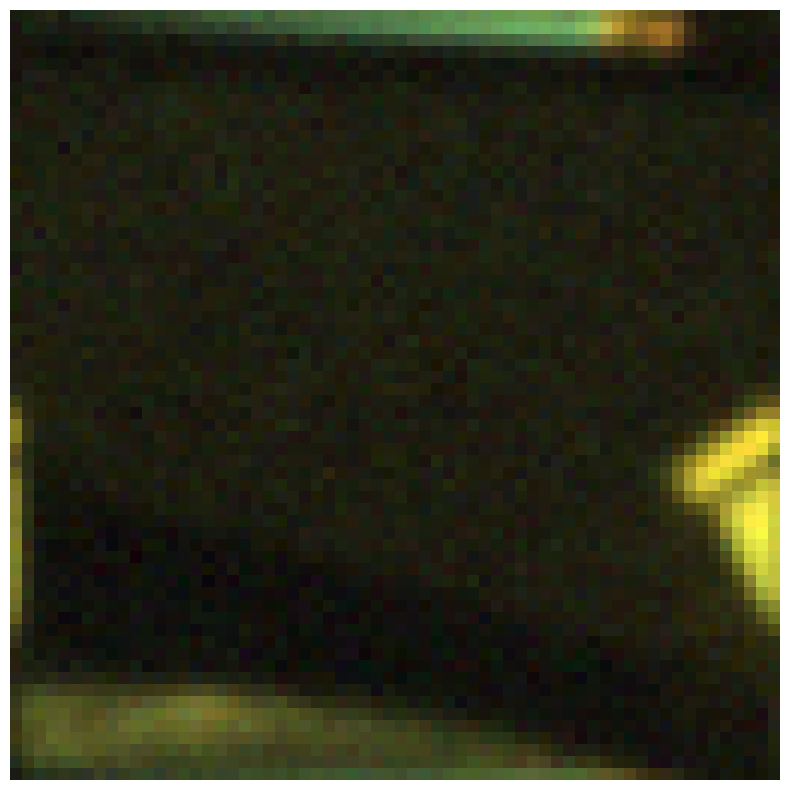

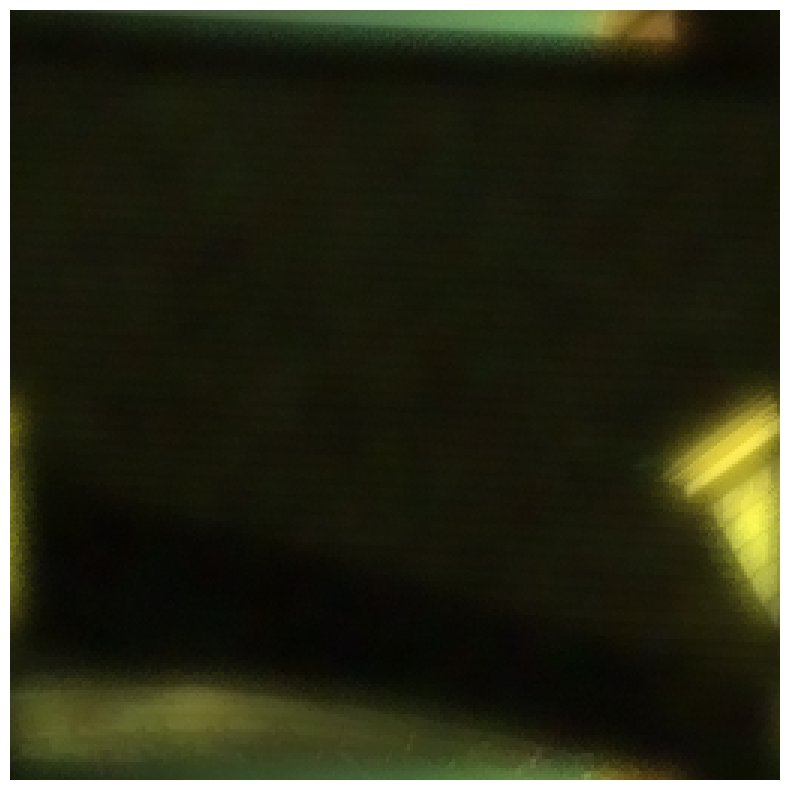

In [510]:
rgb = dataset.rgb_index
x_rgb = X[0, rgb,...].cpu().numpy().transpose(1, 2, 0)
x_rgb = (x_rgb - x_rgb.min())/(x_rgb.max() - x_rgb.min())

y_rgb = Y_H[0, rgb, ...].cpu().numpy().transpose(1, 2, 0)
y_rgb = (y_rgb - y_rgb.min())/(y_rgb.max() - y_rgb.min())

z_rgb = U_cb[0, rgb, ...].cpu().numpy().transpose(1, 2, 0)
z_rgb = (z_rgb - z_rgb.min())/(z_rgb.max() - z_rgb.min())

# plt.figure(figsize=(15, 5))
# plt.subplot(131)
plt.figure(figsize=(10,10))
plt.imshow(x_rgb)
# plt.title('RGB')
plt.axis('off')

# plt.subplot(132)
plt.figure(figsize=(10,10))
plt.imshow(Y_M[0, 0, ...].cpu().numpy(), cmap='gray')
# plt.title('Panchromatic')
plt.axis('off')

# plt.subplot(133)
plt.figure(figsize=(10,10))
plt.imshow(y_rgb)
# plt.title('Noisy RGB')
plt.axis('off')

# plt.subplot(133)
plt.figure(figsize=(10,10))
plt.imshow(z_rgb)
# plt.title('Noisy RGB')
plt.axis('off')

plt.show()

Dimensions vérifiées: iterations (10,), cout_total 10


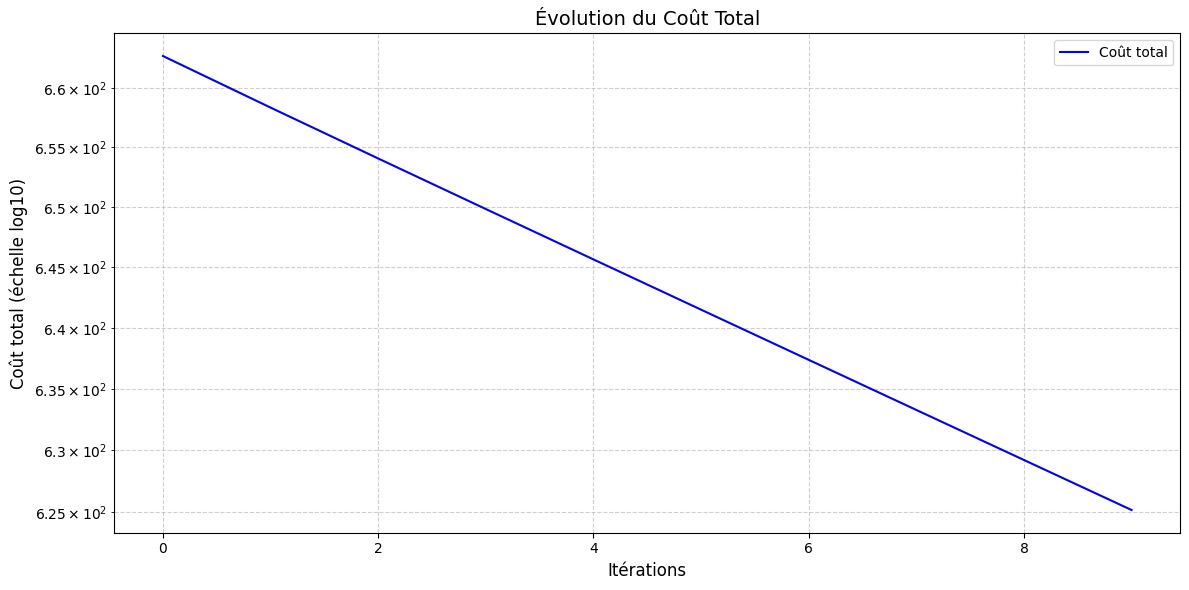

In [511]:
import matplotlib.pyplot as plt
import numpy as np

# Données d'exemple (à adapter avec vos données réelles)
cout_total = costs_gp

# Création du vecteur d'itérations de même longueur que cout_total
iterations = np.arange(0, len(cout_total))  # Pas de 10 entre les mesures

# Vérification des dimensions
print(f"Dimensions vérifiées: iterations {iterations.shape}, cout_total {len(cout_total)}")

# Création du graphique
plt.figure(figsize=(12, 6))
plt.semilogy(iterations, cout_total, 'b-', linewidth=1.5, label='Coût total')

# Personnalisation
plt.xlabel('Itérations', fontsize=12)
plt.ylabel('Coût total (échelle log10)', fontsize=12)
plt.title('Évolution du Coût Total', fontsize=14)
plt.grid(True, which="both", linestyle='--', alpha=0.6)

# Affichage
plt.legend()
plt.tight_layout()
plt.show()

In [512]:
from deepinv.loss.metric import PSNR

m = PSNR()
P = m(U_cb,X)
print(P)

tensor([20.7220])


In [14]:
import torch
from torchvision import transforms
from PIL import Image
to_pil = transforms.ToPILImage()

In [15]:
original = to_pil(x_rgb)
original.save('original.png')

In [16]:
image2 = to_pil(Y_M[0, 0, ...])
image2.save('Pan.png')

In [17]:
image3 = to_pil(y_rgb)
image3.save('low_hsi.png')

In [18]:
image4 = to_pil(z_rgb)
image4.save('reconstructed_grad.png')